# Grenzgletscher — how well do the three parameters fit?

| | parameter | acts on | range |
|---|---|---|---|
| `f_ref` | refreeze_frac | share of melt+rain that percolates and refreezes | 0 – 1 |
| `f_ins` | insul_scale | multiplier on Calonne (2011) snow/firn conductivity (low = insulates more) | 0.3 – 2.0 |
| `f_adv` | advection_scale | multiplier on the depth-averaged ice velocity | 0.3 – 1.7 |

Replaces `perm_frac` / `dT_scale`. Benchmark: **3.19 °C**, the old pair's floor on this glacier
(caveat: that came from runs with `thermal_spinup='n'`, these run with it on).

In [4]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from icetemp.calibration import CalibrationConfig, CalibrationPipeline
from icetemp.calibration.emulator import Emulator, BASAL

RUN_TAG = 'grenz_tuning3'
BASE_NAME = 'Grenzgletscher'
OLD_FLOOR = 3.19
PARAMS = ['refreeze_frac', 'insul_scale', 'advection_scale']
LABELS = ['$f_{ref}$', '$f_{ins}$', '$f_{adv}$']

In [5]:
base = CalibrationConfig.from_yaml('../config/bayescal_centraleurope_25glaciers.yaml')
cfg = CalibrationConfig(region=base.region, include_estimated=base.include_estimated,
                        include_unassessed=base.include_unassessed, run_tag=RUN_TAG,
                        calibration_source_dir=base.calibration_source_dir,
                        calibration_source_files=base.calibration_source_files)
pl = CalibrationPipeline(cfg)
pl.load_data()
glaciers = [g for g in pl.data_handler.calibration_glaciers
            if g.glacier_id and g.base_glacier_name == BASE_NAME]

pd.DataFrame([{'entity': g.glacier_name, 'id': g.glacier_id, 'elev': round(g.elevation),
               'n_obs': g.n_obs, 'z_min': round(g.depths.min(), 1),
               'z_max': round(g.depths.max(), 1),
               'T_min': round(g.T_obs.min(), 2), 'T_max': round(g.T_obs.max(), 2)}
              for g in glaciers])

Calibration glaciers: 116 (equilibrium=true: 56, estimated: 36, unassessed/blank: 24)
  with accumulation-zone (firn) obs: 89
  with ablation-zone (ice) obs:      27
  with data below 30 m:              37
  largest depth-bin pooling factor:  40776 raw readings -> 1 point (continuous-logger dedup)
Prediction (all glenglat) glaciers:  211


,entity,id,elev,n_obs,z_min,z_max,T_min,T_max
0,Grenzgletscher@2015,01225,2015,10,27.8,267.3,-0.73,-0.23
1,Grenzgletscher@2505,01225,2500,12,27.6,106.5,-4.00,-1.39
2,Grenzgletscher@2525,01225,2527,14,19.3,202.1,-2.06,-0.19
3,Grenzgletscher@2605,01225,2600,16,11.3,347.9,-3.84,-0.62
4,Grenzgletscher@3895,01225,3898,9,2.0,18.0,-6.62,-0.23
5,Grenzgletscher@3955,01225,3951,10,3.0,21.0,-6.66,-1.44
6,Grenzgletscher@3985,01225,3985,10,2.0,20.0,-6.53,-0.03
7,Grenzgletscher@3995,01225,3990,11,2.0,22.0,-8.12,-5.20
8,Grenzgletscher@4005,01225,4000,7,1.0,14.0,-7.46,0.00
9,Grenzgletscher@4095,01225,4090,11,1.0,21.0,-11.58,-9.55


## Score every design point

Each observed depth is matched to the model's nearest own grid node, within half the local grid
spacing — the same rule the emulator uses. `BASAL` sentinel rows are dropped, so this is a
like-for-like depth RMSE.

In [6]:
out_dir = Path(cfg.output_path)
design = pd.read_csv(out_dir / 'design.csv')

emu = Emulator(glaciers=glaciers)
is_depth = np.array([d != BASAL for _, d in emu.x_index])
y = np.concatenate([np.append(g.T_obs, np.nan) for g in glaciers])   # BASAL row -> NaN
row_entity = np.concatenate([[g.glacier_name] * (g.n_obs + 1) for g in glaciers])
row_elev = np.concatenate([[g.elevation] * (g.n_obs + 1) for g in glaciers])

recs = []
for i in range(len(design)):
    p = out_dir / 'training_runs' / f'design_{i:04d}.output.pkl'
    if not p.exists():
        continue
    with open(p, 'rb') as f:
        output = pickle.load(f)
    F = emu.assemble_matrix([output])[:, 0]
    ok = is_depth & np.isfinite(F) & np.isfinite(y)
    if ok.sum() == 0:
        continue
    res = F[ok] - y[ok]
    recs.append({'i': i, **dict(zip(design.columns, design.iloc[i].values)),
                 'n_matched': int(ok.sum()),
                 'rmse': float(np.sqrt((res ** 2).mean())),
                 'bias': float(res.mean())})

scores = pd.DataFrame(recs).sort_values('rmse').reset_index(drop=True)
print(f'{len(scores)}/{len(design)} design points scored, '
      f'{scores.n_matched.iloc[0]} of {int(is_depth.sum())} observations matched')
scores.head(10).round(3)

7/48 design points scored, 284 of 376 observations matched


,i,refreeze_frac,insul_scale,advection_scale,n_matched,rmse,bias
0,3,0.428,1.280,1.009,284,2.749,0.007
1,2,0.812,1.616,0.383,284,3.110,1.012
2,5,0.905,1.314,1.266,284,3.271,1.444
3,1,0.766,1.094,1.123,284,3.323,1.643
4,6,0.966,1.177,0.945,284,3.581,1.967
5,0,0.883,0.715,1.318,284,4.373,3.130
6,4,0.703,0.495,0.749,284,4.917,3.784


In [7]:
best = scores.iloc[0]
print(f'best  RMSE {best.rmse:.2f} degC   (old floor {OLD_FLOOR:.2f})   bias {best.bias:+.2f}')
print(f'      f_ref {best.refreeze_frac:.3f}   f_ins {best.insul_scale:.3f}   '
      f'f_adv {best.advection_scale:.3f}')
print(f'worst RMSE {scores.rmse.max():.2f}   spread {scores.rmse.max() - scores.rmse.min():.2f} degC')
print(f'bias range {scores.bias.min():+.2f} .. {scores.bias.max():+.2f} degC')

# Is the optimum pinned against a bound? If so the number is a floor, not a fit.
bounds = {'refreeze_frac': (0.0, 1.0), 'insul_scale': (0.3, 2.0), 'advection_scale': (0.3, 1.7)}
print()
for p in PARAMS:
    lo, hi = bounds[p]
    frac = (best[p] - lo) / (hi - lo)
    flag = '  <-- AT BOUND' if frac < 0.05 or frac > 0.95 else ''
    print(f'{p:16s} {best[p]:.3f}  in [{lo}, {hi}]  ({frac:.0%} of range){flag}')

best  RMSE 2.75 degC   (old floor 3.19)   bias +0.01
      f_ref 0.428   f_ins 1.280   f_adv 1.009
worst RMSE 4.92   spread 2.17 degC
bias range +0.01 .. +3.78 degC

refreeze_frac    0.428  in [0.0, 1.0]  (43% of range)
insul_scale      1.280  in [0.3, 2.0]  (58% of range)
advection_scale  1.009  in [0.3, 1.7]  (51% of range)


## Does each parameter matter?

A flat cloud means the parameter has no leverage on this glacier.

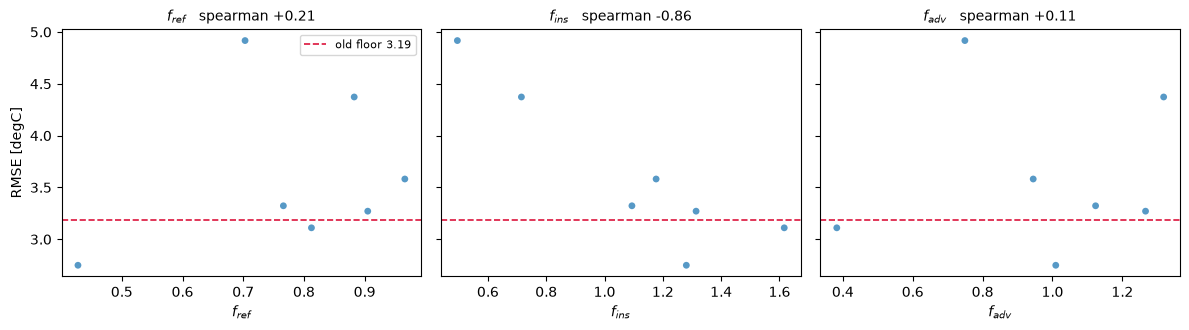

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, p, lab in zip(axes, PARAMS, LABELS):
    ax.scatter(scores[p], scores.rmse, s=24, c='tab:blue', alpha=.75, edgecolor='none')
    ax.axhline(OLD_FLOOR, color='crimson', lw=1.2, ls='--', label=f'old floor {OLD_FLOOR}')
    rho = scores[p].corr(scores.rmse, method='spearman')
    ax.set_xlabel(lab)
    ax.set_title(f'{lab}   spearman {rho:+.2f}', fontsize=10)
axes[0].set_ylabel('RMSE [degC]')
axes[0].legend(fontsize=8)
fig.tight_layout()

## Best fit against the observations

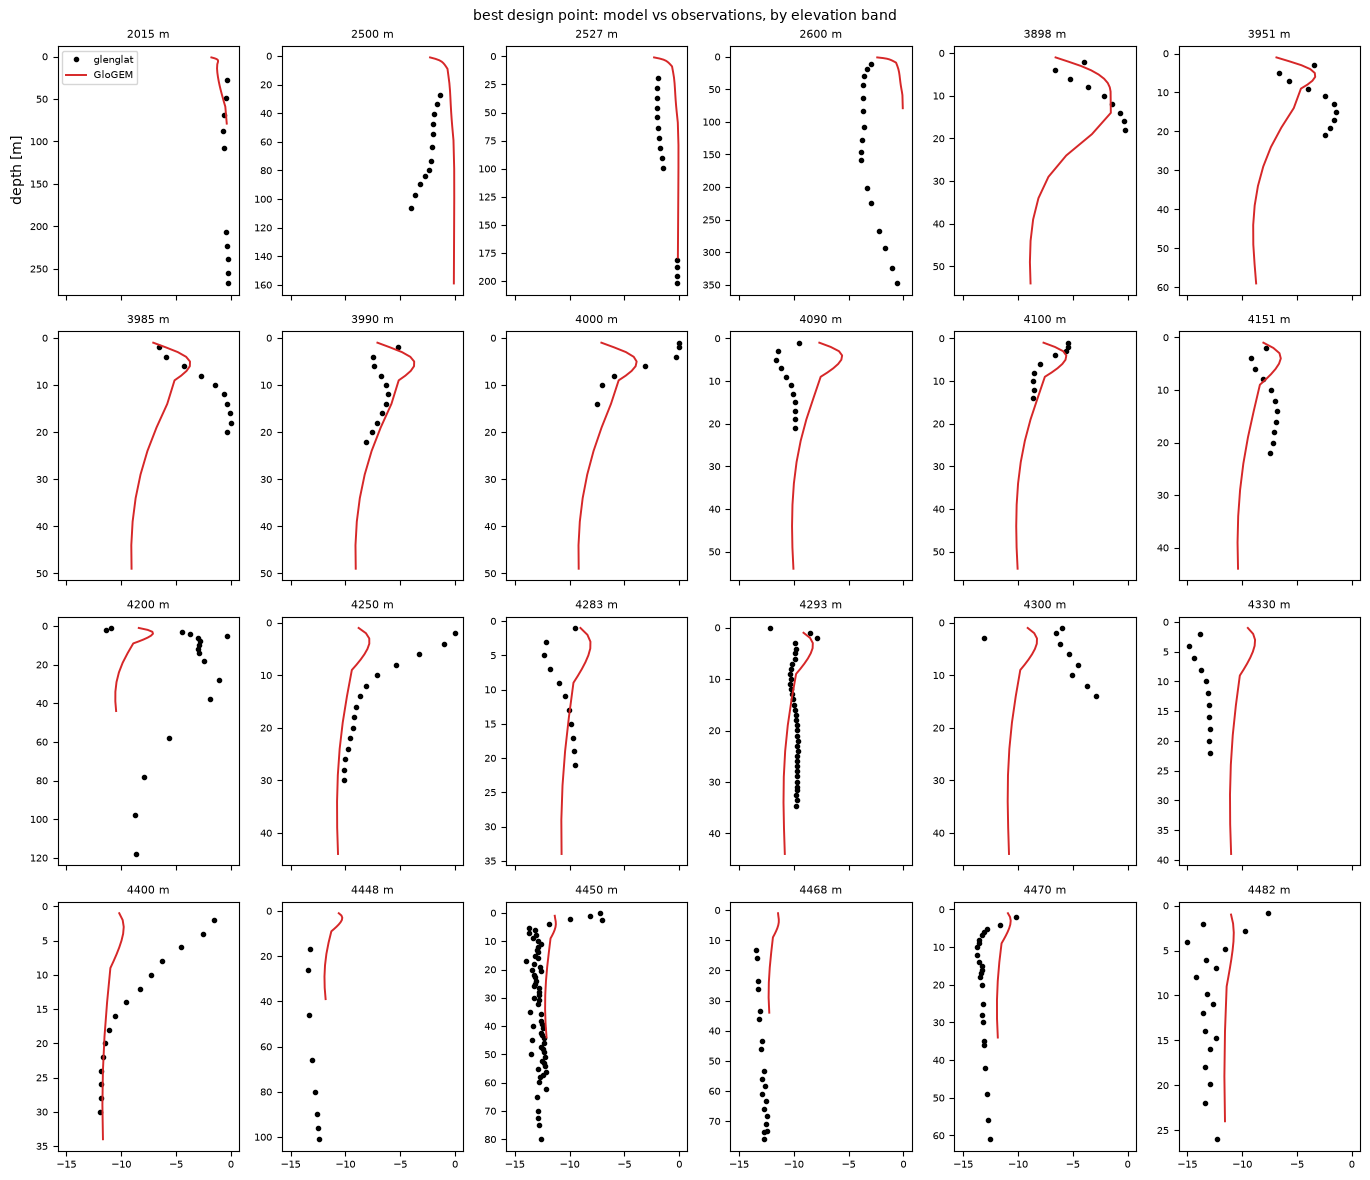

In [9]:
with open(out_dir / 'training_runs' / f'design_{int(best.i):04d}.output.pkl', 'rb') as f:
    best_output = pickle.load(f)

n = len(glaciers)
ncol = 6
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 3.0 * nrow),
                         sharex=True, squeeze=False)
for ax, g in zip(axes.ravel(), glaciers):
    ax.plot(g.T_obs, g.depths, 'o', ms=3, color='k', label='glenglat')
    entry = best_output.get(g.glacier_name)
    if entry is not None:
        d, T = entry
        m = np.isfinite(T)
        ax.plot(np.asarray(T)[m], np.asarray(d)[m], '-', color='tab:red', lw=1.4, label='GloGEM')
    ax.invert_yaxis()
    ax.set_title(f'{round(g.elevation)} m', fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[n:]:
    ax.axis('off')
axes[0][0].set_ylabel('depth [m]')
axes[0][0].legend(fontsize=7)
fig.suptitle('best design point: model vs observations, by elevation band', fontsize=10)
fig.tight_layout()

## Where is the error concentrated?

,n,bias,rmse
elev,,,
2015.0,3,-0.22,0.50
2500.0,11,2.28,2.45
2527.0,11,1.37,1.50
2600.0,4,3.31,3.32
3898.0,8,0.23,2.17
3951.0,9,-1.90,3.40
3985.0,9,-3.15,4.50
3990.0,10,1.18,1.80
4000.0,6,-2.59,4.16


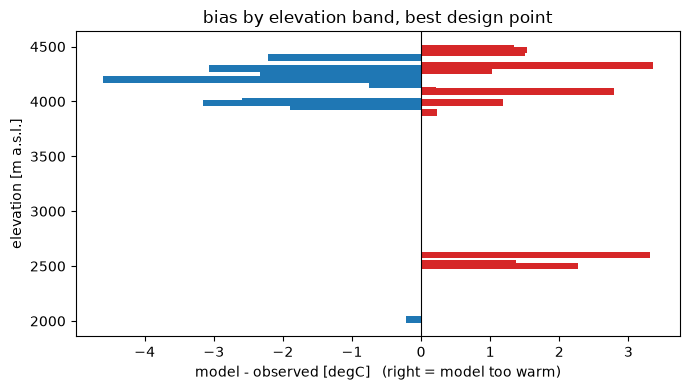

In [10]:
F = emu.assemble_matrix([best_output])[:, 0]
ok = is_depth & np.isfinite(F) & np.isfinite(y)
per = (pd.DataFrame({'elev': row_elev[ok], 'res': F[ok] - y[ok]})
       .groupby('elev')
       .agg(n=('res', 'size'), bias=('res', 'mean'),
            rmse=('res', lambda v: float(np.sqrt((v ** 2).mean())))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(per.index, per.bias, height=60, color=np.where(per.bias > 0, 'tab:red', 'tab:blue'))
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('model - observed [degC]   (right = model too warm)')
ax.set_ylabel('elevation [m a.s.l.]')
ax.set_title('bias by elevation band, best design point')
fig.tight_layout()
per.round(2)

## Where does the optimum sit in the parameter space?

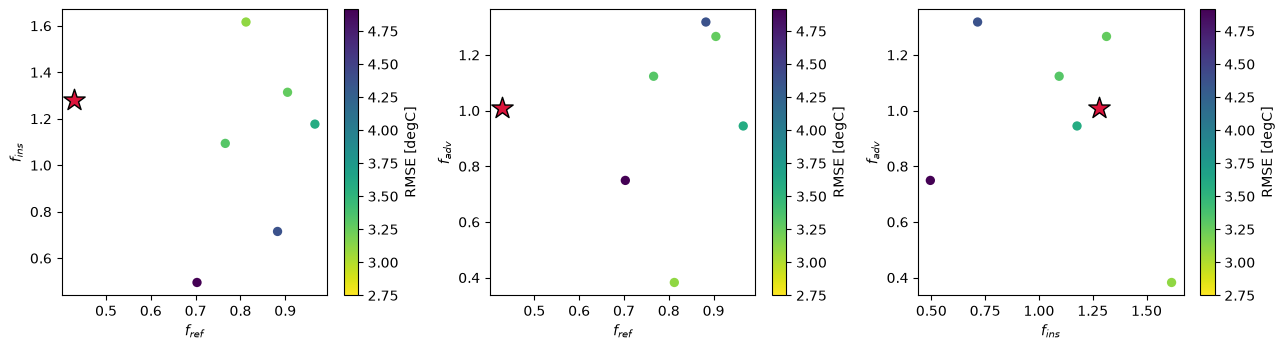

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (a, b) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    s = ax.scatter(scores[PARAMS[a]], scores[PARAMS[b]], c=scores.rmse,
                   cmap='viridis_r', s=45, edgecolor='none')
    ax.scatter(best[PARAMS[a]], best[PARAMS[b]], marker='*', s=260,
               facecolor='crimson', edgecolor='k', zorder=5)
    ax.set_xlabel(LABELS[a])
    ax.set_ylabel(LABELS[b])
    fig.colorbar(s, ax=ax, label='RMSE [degC]')
fig.tight_layout()